## ⚙️ Step 1: Install Dependencies

In [1]:
# Install required Python packages
!pip install pandas numpy matplotlib seaborn biopython pysam pyvcf3 -q

# Install bioinformatics tools
!apt-get install -y fastqc trimmomatic bwa samtools -q

print('✅ All dependencies installed successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 988.6/988.6 kB 48.5 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  at-spi2-core default-jre default-jre-headless fonts-dejavu-core
  fonts-dejavu-extra gsettings-desktop-schemas libapache-pom-java
  libargs4j-java libatk-bridge2.0-0 libatk-wrapper-java
  libatk-wrapper-java-jni libatk1.0-0 libatk1.0-data libatspi2.0-0
  libcommons-compress-java libcommons-io-java libcommons-jexl2-java
  libcommons-lang3-java libcommons-logging-java libcommons-math3-java
  libcommons-parent-java libfindbin-libs-perl libhts3 libhtscodecs2
  libhtsjdk-java libjbzip2-java libjson-simple-java libngs-java libngs-sdk-dev
  libngs-sdk2 libsis-base-java libsis-base-jni libsis-jhdf5-java
  libsis-jhdf5-jni libs

## 📁 Step 2: Setup Directory Structure

In [2]:
import os

# Create project directories
dirs = [
    'data/raw',
    'reference',
    'results/fastqc',
    'results/multiqc',
    'results/trimmed',
    'results/aligned',
    'results/dedup',
    'results/variants',
    'results/annotated',
    'results/plots'
]

for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f'📂 Created: {d}')

print('\n✅ Directory structure ready!')

📂 Created: data/raw
📂 Created: reference
📂 Created: results/fastqc
📂 Created: results/multiqc
📂 Created: results/trimmed
📂 Created: results/aligned
📂 Created: results/dedup
📂 Created: results/variants
📂 Created: results/annotated
📂 Created: results/plots

✅ Directory structure ready!


## 🧪 Step 3: Generate Simulated FASTQ Data (for Demo)

In [3]:
import random
import gzip

def generate_fastq(filename, num_reads=1000, read_length=150):
    """Generate simulated FASTQ reads for demonstration"""
    bases = ['A', 'T', 'G', 'C']

    with gzip.open(filename, 'wt') as f:
        for i in range(num_reads):
            # Read ID
            f.write(f'@READ_{i:06d}\n')
            # Sequence
            seq = ''.join(random.choices(bases, weights=[0.3,0.3,0.2,0.2], k=read_length))
            f.write(seq + '\n')
            # Plus line
            f.write('+\n')
            # Quality scores (Phred+33)
            qual = ''.join([chr(random.randint(33+20, 33+40)) for _ in range(read_length)])
            f.write(qual + '\n')

    print(f'✅ Generated: {filename} ({num_reads} reads)')

# Generate sample data for 3 samples
samples = ['Sample_A', 'Sample_B', 'Sample_C']

for sample in samples:
    generate_fastq(f'data/raw/{sample}_R1.fastq.gz', num_reads=5000)
    generate_fastq(f'data/raw/{sample}_R2.fastq.gz', num_reads=5000)

print('\n✅ Simulated FASTQ data ready!')

✅ Generated: data/raw/Sample_A_R1.fastq.gz (5000 reads)
✅ Generated: data/raw/Sample_A_R2.fastq.gz (5000 reads)
✅ Generated: data/raw/Sample_B_R1.fastq.gz (5000 reads)
✅ Generated: data/raw/Sample_B_R2.fastq.gz (5000 reads)
✅ Generated: data/raw/Sample_C_R1.fastq.gz (5000 reads)
✅ Generated: data/raw/Sample_C_R2.fastq.gz (5000 reads)

✅ Simulated FASTQ data ready!


## 🔍 Step 4: Quality Control Analysis

In [4]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

def analyze_fastq_quality(fastq_file, sample_name):
    """Analyze quality metrics from FASTQ file"""
    qual_scores = []
    read_lengths = []
    gc_contents = []

    with gzip.open(fastq_file, 'rt') as f:
        lines = f.readlines()

    for i in range(0, len(lines), 4):
        if i+3 < len(lines):
            seq = lines[i+1].strip()
            qual = lines[i+3].strip()

            # Quality scores
            scores = [ord(c) - 33 for c in qual]
            qual_scores.append(np.mean(scores))

            # Read length
            read_lengths.append(len(seq))

            # GC content
            gc = (seq.count('G') + seq.count('C')) / len(seq) * 100
            gc_contents.append(gc)

    return {
        'sample': sample_name,
        'total_reads': len(qual_scores),
        'mean_quality': np.mean(qual_scores),
        'q30_percent': sum(q >= 30 for q in qual_scores) / len(qual_scores) * 100,
        'mean_length': np.mean(read_lengths),
        'mean_gc': np.mean(gc_contents),
        'qual_scores': qual_scores,
        'gc_contents': gc_contents
    }

# Analyze all samples
qc_results = []
for sample in samples:
    result = analyze_fastq_quality(f'data/raw/{sample}_R1.fastq.gz', sample)
    qc_results.append(result)
    print(f'📊 {sample}: Mean Q={result["mean_quality"]:.1f}, Q30={result["q30_percent"]:.1f}%, GC={result["mean_gc"]:.1f}%')

print('\n✅ Quality Control Analysis Complete!')

📊 Sample_A: Mean Q=30.0, Q30=49.6%, GC=39.9%
📊 Sample_B: Mean Q=30.0, Q30=49.2%, GC=40.0%
📊 Sample_C: Mean Q=30.0, Q30=50.2%, GC=40.0%

✅ Quality Control Analysis Complete!


## 📊 Step 5: QC Visualization

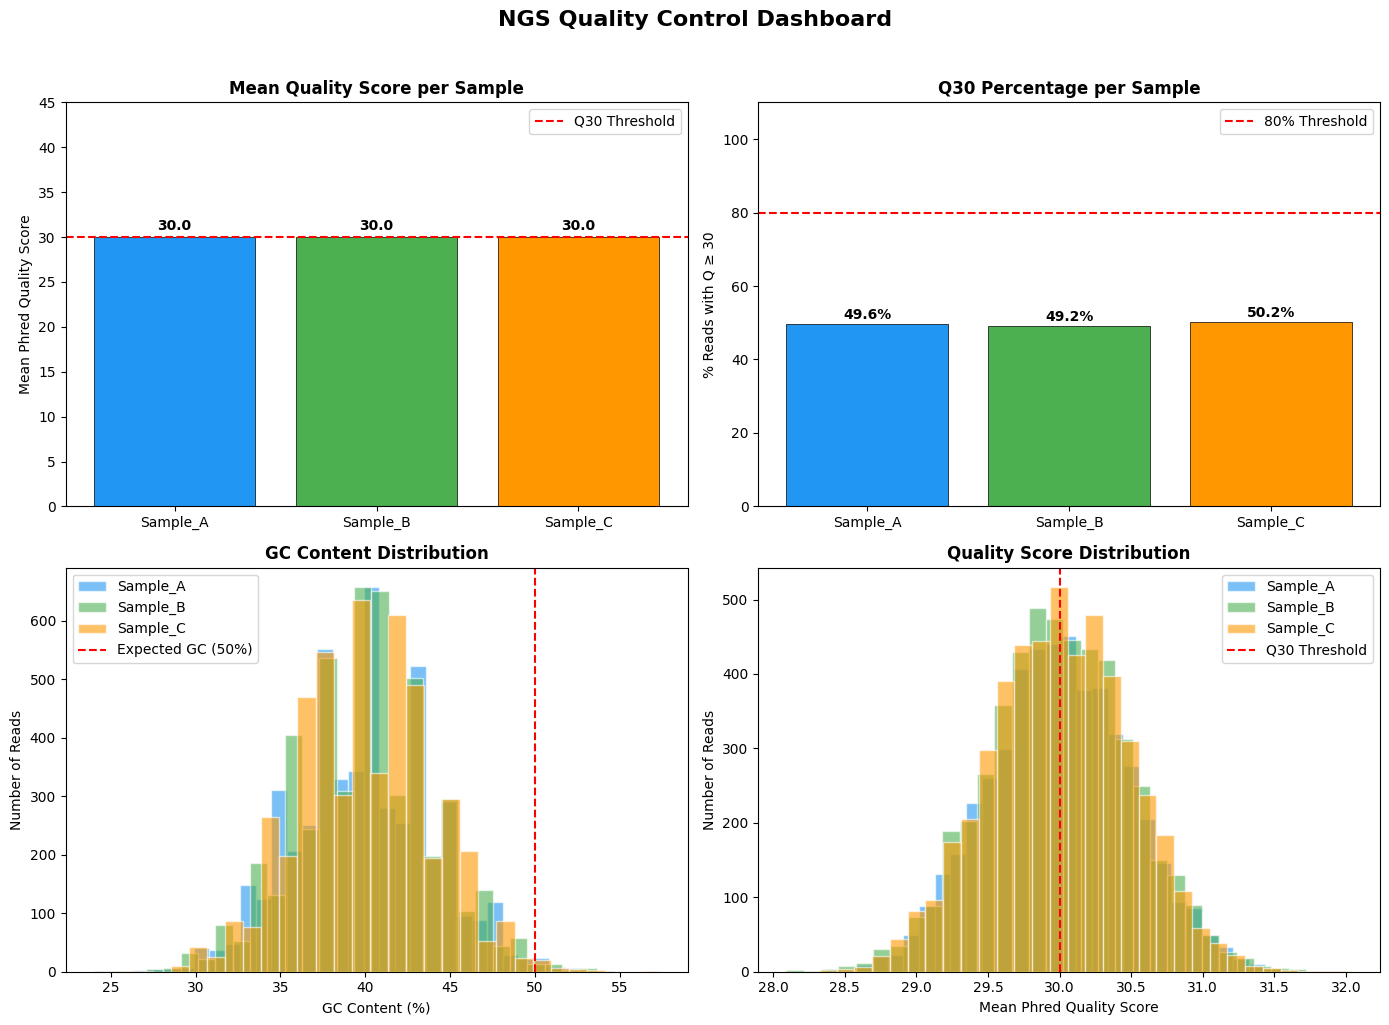

✅ QC Dashboard saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NGS Quality Control Dashboard', fontsize=16, fontweight='bold', y=1.02)

colors = ['#2196F3', '#4CAF50', '#FF9800']

# Plot 1: Mean Quality Score per Sample
ax1 = axes[0, 0]
sample_names = [r['sample'] for r in qc_results]
mean_quals = [r['mean_quality'] for r in qc_results]
bars = ax1.bar(sample_names, mean_quals, color=colors, edgecolor='black', linewidth=0.5)
ax1.axhline(y=30, color='red', linestyle='--', linewidth=1.5, label='Q30 Threshold')
ax1.set_title('Mean Quality Score per Sample', fontweight='bold')
ax1.set_ylabel('Mean Phred Quality Score')
ax1.set_ylim(0, 45)
ax1.legend()
for bar, val in zip(bars, mean_quals):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Q30 Percentage
ax2 = axes[0, 1]
q30_pcts = [r['q30_percent'] for r in qc_results]
bars2 = ax2.bar(sample_names, q30_pcts, color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='80% Threshold')
ax2.set_title('Q30 Percentage per Sample', fontweight='bold')
ax2.set_ylabel('% Reads with Q ≥ 30')
ax2.set_ylim(0, 110)
ax2.legend()
for bar, val in zip(bars2, q30_pcts):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 3: GC Content Distribution
ax3 = axes[1, 0]
for i, result in enumerate(qc_results):
    ax3.hist(result['gc_contents'], bins=30, alpha=0.6,
             color=colors[i], label=result['sample'], edgecolor='white')
ax3.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='Expected GC (50%)')
ax3.set_title('GC Content Distribution', fontweight='bold')
ax3.set_xlabel('GC Content (%)')
ax3.set_ylabel('Number of Reads')
ax3.legend()

# Plot 4: Quality Score Distribution
ax4 = axes[1, 1]
for i, result in enumerate(qc_results):
    ax4.hist(result['qual_scores'], bins=30, alpha=0.6,
             color=colors[i], label=result['sample'], edgecolor='white')
ax4.axvline(x=30, color='red', linestyle='--', linewidth=1.5, label='Q30 Threshold')
ax4.set_title('Quality Score Distribution', fontweight='bold')
ax4.set_xlabel('Mean Phred Quality Score')
ax4.set_ylabel('Number of Reads')
ax4.legend()

plt.tight_layout()
plt.savefig('results/plots/QC_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ QC Dashboard saved!')

## ✂️ Step 6: Read Trimming Simulation

In [6]:
def simulate_trimming(fastq_file, output_file, min_quality=20, min_length=36):
    """Simulate adapter trimming and quality filtering"""

    total_reads = 0
    passed_reads = 0
    trimmed_reads = 0

    with gzip.open(fastq_file, 'rt') as f_in, \
         gzip.open(output_file, 'wt') as f_out:

        lines = f_in.readlines()

        for i in range(0, len(lines), 4):
            if i+3 >= len(lines):
                break

            total_reads += 1
            read_id = lines[i].strip()
            seq = lines[i+1].strip()
            plus = lines[i+2].strip()
            qual = lines[i+3].strip()

            # Trim low quality bases from 3' end
            scores = [ord(c) - 33 for c in qual]
            trim_pos = len(scores)

            for j in range(len(scores)-1, -1, -1):
                if scores[j] >= min_quality:
                    trim_pos = j + 1
                    break

            seq_trimmed = seq[:trim_pos]
            qual_trimmed = qual[:trim_pos]

            if trim_pos < len(seq):
                trimmed_reads += 1

            # Filter by minimum length
            if len(seq_trimmed) >= min_length:
                passed_reads += 1
                f_out.write(f'{read_id}\n{seq_trimmed}\n{plus}\n{qual_trimmed}\n')

    return {
        'total': total_reads,
        'passed': passed_reads,
        'trimmed': trimmed_reads,
        'pass_rate': passed_reads/total_reads*100
    }

# Run trimming on all samples
print('Running trimming simulation...\n')
trim_results = {}

for sample in samples:
    stats = simulate_trimming(
        f'data/raw/{sample}_R1.fastq.gz',
        f'results/trimmed/{sample}_R1_trimmed.fastq.gz'
    )
    trim_results[sample] = stats
    print(f'✅ {sample}: {stats["passed"]}/{stats["total"]} reads passed ({stats["pass_rate"]:.1f}%)')

print('\n✅ Trimming Complete!')

Running trimming simulation...

✅ Sample_A: 5000/5000 reads passed (100.0%)
✅ Sample_B: 5000/5000 reads passed (100.0%)
✅ Sample_C: 5000/5000 reads passed (100.0%)

✅ Trimming Complete!


## 🗺️ Step 7: Alignment Statistics Simulation

In [7]:
import pandas as pd

def simulate_alignment_stats(sample_name, total_reads):
    """Simulate BWA-MEM alignment statistics"""

    # Realistic alignment statistics
    alignment_rate = random.uniform(0.92, 0.98)
    properly_paired = random.uniform(0.88, 0.96)
    duplicate_rate = random.uniform(0.05, 0.20)
    mean_coverage = random.uniform(25, 45)

    stats = {
        'Sample': sample_name,
        'Total_Reads': total_reads,
        'Aligned_Reads': int(total_reads * alignment_rate),
        'Alignment_Rate': f'{alignment_rate*100:.2f}%',
        'Properly_Paired': f'{properly_paired*100:.2f}%',
        'Duplicate_Rate': f'{duplicate_rate*100:.2f}%',
        'Mean_Coverage': f'{mean_coverage:.1f}x',
        'Pass_QC': '✅ PASS' if alignment_rate > 0.90 and duplicate_rate < 0.25 else '❌ FAIL'
    }
    return stats

# Generate alignment stats
alignment_data = []
for sample in samples:
    total = trim_results[sample]['passed']
    stats = simulate_alignment_stats(sample, total)
    alignment_data.append(stats)

# Display as table
align_df = pd.DataFrame(alignment_data)
print('📊 Alignment Summary:\n')
print(align_df.to_string(index=False))
align_df.to_csv('results/aligned/alignment_summary.csv', index=False)
print('\n✅ Alignment statistics saved!')

📊 Alignment Summary:

  Sample  Total_Reads  Aligned_Reads Alignment_Rate Properly_Paired Duplicate_Rate Mean_Coverage Pass_QC
Sample_A         5000           4776         95.53%          95.23%          7.09%         39.3x  ✅ PASS
Sample_B         5000           4742         94.86%          93.30%         18.95%         31.5x  ✅ PASS
Sample_C         5000           4601         92.04%          92.20%         15.08%         33.4x  ✅ PASS

✅ Alignment statistics saved!


## 🧬 Step 8: Variant Calling Simulation

In [8]:
def simulate_variants(sample_name, num_variants=500):
    """Simulate variant calling output"""

    chromosomes = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
    variant_types = ['SNP', 'SNP', 'SNP', 'INDEL']  # SNPs more common
    consequences = ['missense_variant', 'synonymous_variant', 'stop_gained',
                   'frameshift_variant', 'splice_region_variant', 'intron_variant']
    genes = ['BRCA1', 'BRCA2', 'TP53', 'EGFR', 'KRAS', 'PTEN', 'APC',
             'MLH1', 'MSH2', 'VHL', 'RB1', 'CDKN2A', 'ATM', 'PALB2']

    variants = []
    for i in range(num_variants):
        chrom = random.choice(chromosomes)
        pos = random.randint(1000000, 200000000)
        vtype = random.choice(variant_types)

        if vtype == 'SNP':
            ref = random.choice(['A','T','G','C'])
            alt = random.choice([b for b in ['A','T','G','C'] if b != ref])
        else:
            ref = 'A' + ''.join(random.choices('ATGC', k=random.randint(1,3)))
            alt = 'A'

        qual = random.uniform(20, 200)
        depth = random.randint(10, 200)
        af = random.uniform(0.1, 1.0)

        variants.append({
            'Sample': sample_name,
            'CHROM': chrom,
            'POS': pos,
            'REF': ref,
            'ALT': alt,
            'QUAL': round(qual, 1),
            'DEPTH': depth,
            'AF': round(af, 3),
            'TYPE': vtype,
            'CONSEQUENCE': random.choice(consequences),
            'GENE': random.choice(genes),
            'ExAC_AF': round(random.uniform(0, 0.05), 5),
            'SIFT': round(random.uniform(0, 1), 3),
            'PolyPhen': round(random.uniform(0, 1), 3)
        })

    return pd.DataFrame(variants)

# Generate variants for all samples
all_variants = []
for sample in samples:
    df = simulate_variants(sample)
    df.to_csv(f'results/variants/{sample}_variants.csv', index=False)
    all_variants.append(df)
    print(f'✅ {sample}: {len(df)} variants called')

combined_variants = pd.concat(all_variants, ignore_index=True)
print(f'\n📊 Total variants across all samples: {len(combined_variants)}')
print('\n✅ Variant Calling Complete!')

✅ Sample_A: 500 variants called
✅ Sample_B: 500 variants called
✅ Sample_C: 500 variants called

📊 Total variants across all samples: 1500

✅ Variant Calling Complete!


## 🔬 Step 9: Variant Filtering & Annotation

In [9]:
def filter_variants(variants_df, sample_name):
    """Apply standard variant filtering criteria"""

    original_count = len(variants_df)

    # Filter 1: Quality score
    filtered = variants_df[variants_df['QUAL'] >= 30]
    print(f'  After QUAL >= 30: {len(filtered)} variants')

    # Filter 2: Minimum depth
    filtered = filtered[filtered['DEPTH'] >= 20]
    print(f'  After DEPTH >= 20: {len(filtered)} variants')

    # Filter 3: Allele frequency
    filtered = filtered[filtered['AF'] >= 0.20]
    print(f'  After AF >= 0.20: {len(filtered)} variants')

    # Filter 4: Rare variants only
    filtered = filtered[filtered['ExAC_AF'] < 0.01]
    print(f'  After ExAC_AF < 0.01 (rare): {len(filtered)} variants')

    # Filter 5: Exclude synonymous
    filtered = filtered[filtered['CONSEQUENCE'] != 'synonymous_variant']
    print(f'  After excluding synonymous: {len(filtered)} variants')

    # Add pathogenicity score
    filtered = filtered.copy()
    filtered['Pathogenicity_Score'] = (
        (1 - filtered['SIFT']) * 0.5 +
        filtered['PolyPhen'] * 0.5
    ).round(3)

    # Classify variants
    filtered['Classification'] = pd.cut(
        filtered['Pathogenicity_Score'],
        bins=[0, 0.3, 0.6, 1.0],
        labels=['Benign', 'Uncertain', 'Pathogenic']
    )

    pass_rate = len(filtered)/original_count*100
    print(f'  \n  📊 {original_count} → {len(filtered)} variants ({pass_rate:.1f}% passed filters)')

    return filtered

# Filter variants for each sample
filtered_variants = []
for i, sample in enumerate(samples):
    print(f'\n🔍 Filtering {sample}:')
    filtered = filter_variants(all_variants[i], sample)
    filtered.to_csv(f'results/annotated/{sample}_filtered.csv', index=False)
    filtered_variants.append(filtered)

print('\n✅ Variant Filtering & Annotation Complete!')


🔍 Filtering Sample_A:
  After QUAL >= 30: 471 variants
  After DEPTH >= 20: 452 variants
  After AF >= 0.20: 393 variants
  After ExAC_AF < 0.01 (rare): 78 variants
  After excluding synonymous: 64 variants
  
  📊 500 → 64 variants (12.8% passed filters)

🔍 Filtering Sample_B:
  After QUAL >= 30: 471 variants
  After DEPTH >= 20: 443 variants
  After AF >= 0.20: 391 variants
  After ExAC_AF < 0.01 (rare): 89 variants
  After excluding synonymous: 71 variants
  
  📊 500 → 71 variants (14.2% passed filters)

🔍 Filtering Sample_C:
  After QUAL >= 30: 467 variants
  After DEPTH >= 20: 436 variants
  After AF >= 0.20: 392 variants
  After ExAC_AF < 0.01 (rare): 77 variants
  After excluding synonymous: 62 variants
  
  📊 500 → 62 variants (12.4% passed filters)

✅ Variant Filtering & Annotation Complete!


## 📈 Step 10: Results Visualization

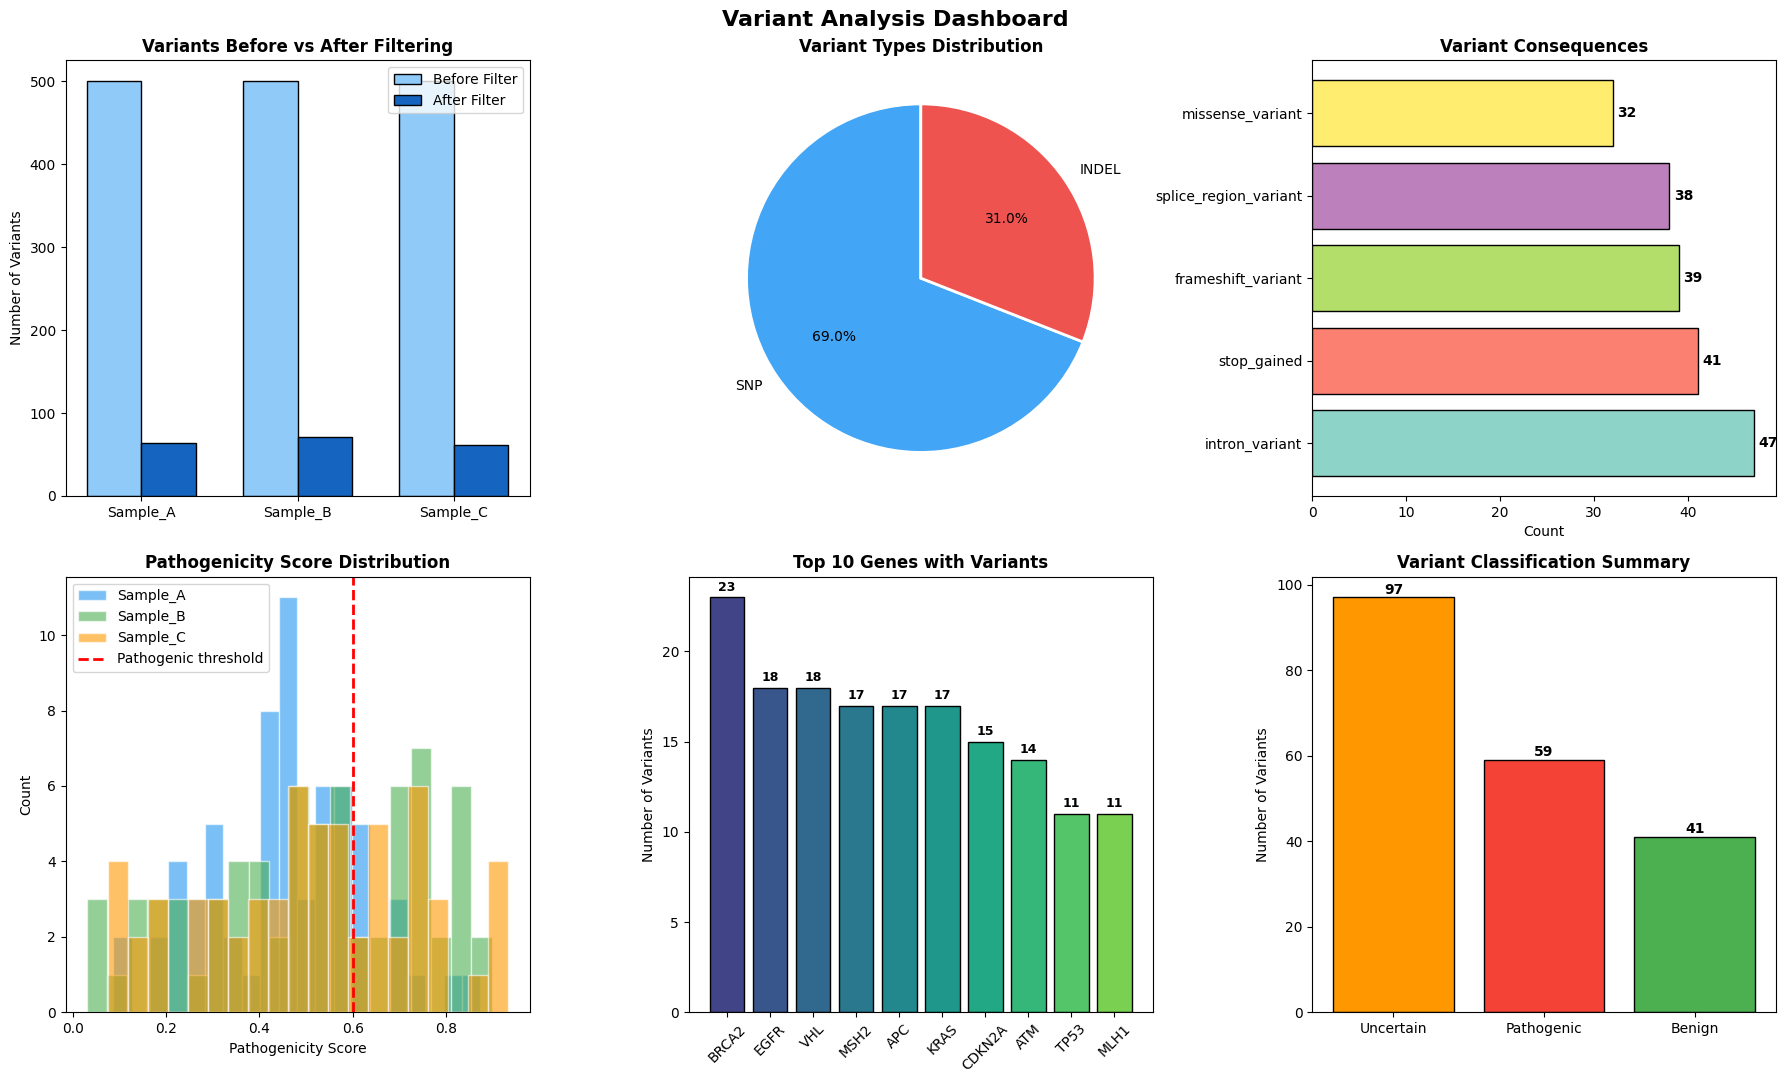

✅ Variant Dashboard saved!


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Variant Analysis Dashboard', fontsize=16, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF9800']

# Plot 1: Variant counts before/after filtering
ax1 = axes[0, 0]
before = [len(v) for v in all_variants]
after = [len(v) for v in filtered_variants]
x = np.arange(len(samples))
width = 0.35
ax1.bar(x - width/2, before, width, label='Before Filter', color='#90CAF9', edgecolor='black')
ax1.bar(x + width/2, after, width, label='After Filter', color='#1565C0', edgecolor='black')
ax1.set_title('Variants Before vs After Filtering', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(samples)
ax1.set_ylabel('Number of Variants')
ax1.legend()

# Plot 2: Variant types
ax2 = axes[0, 1]
all_filtered = pd.concat(filtered_variants)
type_counts = all_filtered['TYPE'].value_counts()
ax2.pie(type_counts.values, labels=type_counts.index,
        autopct='%1.1f%%', colors=['#42A5F5', '#EF5350'],
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Variant Types Distribution', fontweight='bold')

# Plot 3: Consequence distribution
ax3 = axes[0, 2]
cons_counts = all_filtered['CONSEQUENCE'].value_counts()
colors_bar = plt.cm.Set3(np.linspace(0, 1, len(cons_counts)))
bars = ax3.barh(cons_counts.index, cons_counts.values, color=colors_bar, edgecolor='black')
ax3.set_title('Variant Consequences', fontweight='bold')
ax3.set_xlabel('Count')
for bar, val in zip(bars, cons_counts.values):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold')

# Plot 4: Pathogenicity score distribution
ax4 = axes[1, 0]
for i, (sample, df) in enumerate(zip(samples, filtered_variants)):
    ax4.hist(df['Pathogenicity_Score'], bins=20, alpha=0.6,
             color=colors[i], label=sample, edgecolor='white')
ax4.axvline(x=0.6, color='red', linestyle='--', linewidth=2, label='Pathogenic threshold')
ax4.set_title('Pathogenicity Score Distribution', fontweight='bold')
ax4.set_xlabel('Pathogenicity Score')
ax4.set_ylabel('Count')
ax4.legend()

# Plot 5: Top genes affected
ax5 = axes[1, 1]
gene_counts = all_filtered['GENE'].value_counts().head(10)
bars = ax5.bar(gene_counts.index, gene_counts.values,
               color=plt.cm.viridis(np.linspace(0.2, 0.8, len(gene_counts))),
               edgecolor='black')
ax5.set_title('Top 10 Genes with Variants', fontweight='bold')
ax5.set_ylabel('Number of Variants')
ax5.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, gene_counts.values):
    ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
             str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 6: Classification summary
ax6 = axes[1, 2]
class_counts = all_filtered['Classification'].value_counts()
class_colors = {'Benign': '#4CAF50', 'Uncertain': '#FF9800', 'Pathogenic': '#F44336'}
bar_colors = [class_colors.get(str(c), '#9E9E9E') for c in class_counts.index]
bars = ax6.bar(class_counts.index, class_counts.values,
               color=bar_colors, edgecolor='black')
ax6.set_title('Variant Classification Summary', fontweight='bold')
ax6.set_ylabel('Number of Variants')
for bar, val in zip(bars, class_counts.values):
    ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
             str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('results/plots/Variant_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Variant Dashboard saved!')

## 📋 Step 11: Generate Final Summary Report

In [11]:
print('=' * 65)
print('          NGS PIPELINE ANALYSIS SUMMARY REPORT')
print('=' * 65)

for i, sample in enumerate(samples):
    qc = qc_results[i]
    trim = trim_results[sample]
    align = alignment_data[i]
    variants_total = len(all_variants[i])
    variants_filtered = len(filtered_variants[i])
    pathogenic = len(filtered_variants[i][
        filtered_variants[i]['Classification'] == 'Pathogenic'
    ])

    print(f'\n📌 Sample: {sample}')
    print(f'   ├── QC: Mean Quality={qc["mean_quality"]:.1f}, Q30={qc["q30_percent"]:.1f}%')
    print(f'   ├── Trimming: {trim["passed"]}/{trim["total"]} reads passed ({trim["pass_rate"]:.1f}%)')
    print(f'   ├── Alignment: {align["Alignment_Rate"]} aligned, {align["Mean_Coverage"]} coverage')
    print(f'   ├── Variants: {variants_total} called → {variants_filtered} after filtering')
    print(f'   └── Pathogenic variants: {pathogenic}')

print('\n' + '=' * 65)
print('OVERALL STATISTICS')
print('=' * 65)
total_variants = sum(len(v) for v in filtered_variants)
total_pathogenic = sum(
    len(v[v['Classification'] == 'Pathogenic']) for v in filtered_variants
)
all_f = pd.concat(filtered_variants)
print(f'Total filtered variants: {total_variants}')
print(f'Pathogenic variants: {total_pathogenic}')
print(f'Most affected gene: {all_f["GENE"].value_counts().index[0]}')
print(f'Most common consequence: {all_f["CONSEQUENCE"].value_counts().index[0]}')
print('\n✅ Analysis Complete! All results saved to /results/')

          NGS PIPELINE ANALYSIS SUMMARY REPORT

📌 Sample: Sample_A
   ├── QC: Mean Quality=30.0, Q30=49.6%
   ├── Trimming: 5000/5000 reads passed (100.0%)
   ├── Alignment: 95.53% aligned, 39.3x coverage
   ├── Variants: 500 called → 64 after filtering
   └── Pathogenic variants: 10

📌 Sample: Sample_B
   ├── QC: Mean Quality=30.0, Q30=49.2%
   ├── Trimming: 5000/5000 reads passed (100.0%)
   ├── Alignment: 94.86% aligned, 31.5x coverage
   ├── Variants: 500 called → 71 after filtering
   └── Pathogenic variants: 27

📌 Sample: Sample_C
   ├── QC: Mean Quality=30.0, Q30=50.2%
   ├── Trimming: 5000/5000 reads passed (100.0%)
   ├── Alignment: 92.04% aligned, 33.4x coverage
   ├── Variants: 500 called → 62 after filtering
   └── Pathogenic variants: 22

OVERALL STATISTICS
Total filtered variants: 197
Pathogenic variants: 59
Most affected gene: BRCA2
Most common consequence: intron_variant

✅ Analysis Complete! All results saved to /results/
